In [5]:
!pip install portpy cvxpy clarabel scipy matplotlib numpy h5py datasets huggingface_hub

  Using cached portpy-1.1.4-py3-none-any.whl.metadata (28 kB)
  Using cached cvxpy-1.8.2-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-1.11.0-py3-none-any.whl.metadata (14 kB)
  Using cached ecos-2.0.14.tar.gz (142 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Us

  error: subprocess-exited-with-error
  
  × Building wheel for ecos (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      C:\Users\chatu\AppData\Local\Temp\pip-build-env-vype92pv\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\ecos
      copying src\ecos\ecos.py -> build\lib.win-amd64-cpython-314\ecos
      copying src\ecos\version.py -> build\lib.win-amd64-cpython-314\ecos
      copying src\ecos\__init__.py -> build\lib.win-amd64-cpython-314\ecos
      running build_ext
      building '_ecos' extension
      error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/
      [end of output]
  
  note: This error originates from a subprocess, 

c:\Users\chatu\Downloads\604_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching ... files: 261it [04:39,  1.07s/it]


Planner beams: 7, beamlets per beam: [544, 714, 748, 680, 578, 544, 612]
Total beamlets: 4420

=== Baseline (no reg) ===
Status : optimal  [OSQP]
F1     : 0.0013
F2     : 0.0014
Time   : 229.6s
OSQP failed, falling back to SCS: Problem could not be reduced to a QP, and no conic solvers exist among candidate solvers ({'qp_solvers': ['OSQP'], 'conic_solvers': []}).

=== Combined spectral (Fro+Group), λ=0.001 ===
Status : optimal  [SCS]
F1     : 0.0028
F2     : 0.0033
Time   : 67.8s
OSQP failed, falling back to SCS: Problem could not be reduced to a QP, and no conic solvers exist among candidate solvers ({'qp_solvers': ['OSQP'], 'conic_solvers': []}).

=== Combined spectral (Fro+Group), λ=0.003 ===
Status : optimal  [SCS]
F1     : 0.0093
F2     : 0.0057
Time   : 63.3s

Full metrics table:
                    status solver  solve_time_s  D95_ptv  D05_ptv  Dmean_ptv  \
label                                                                          
λ=0.0, reg=fro     optimal   OSQP         2

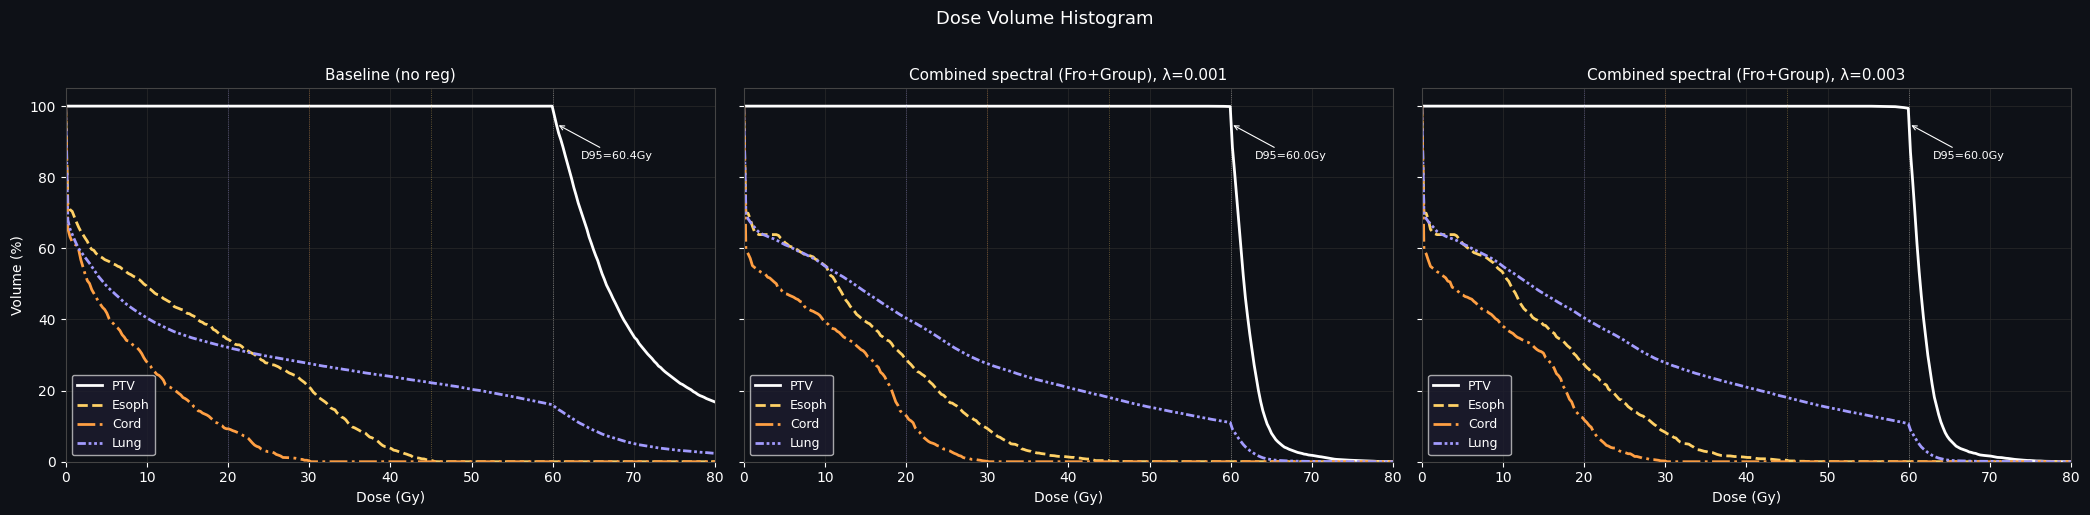

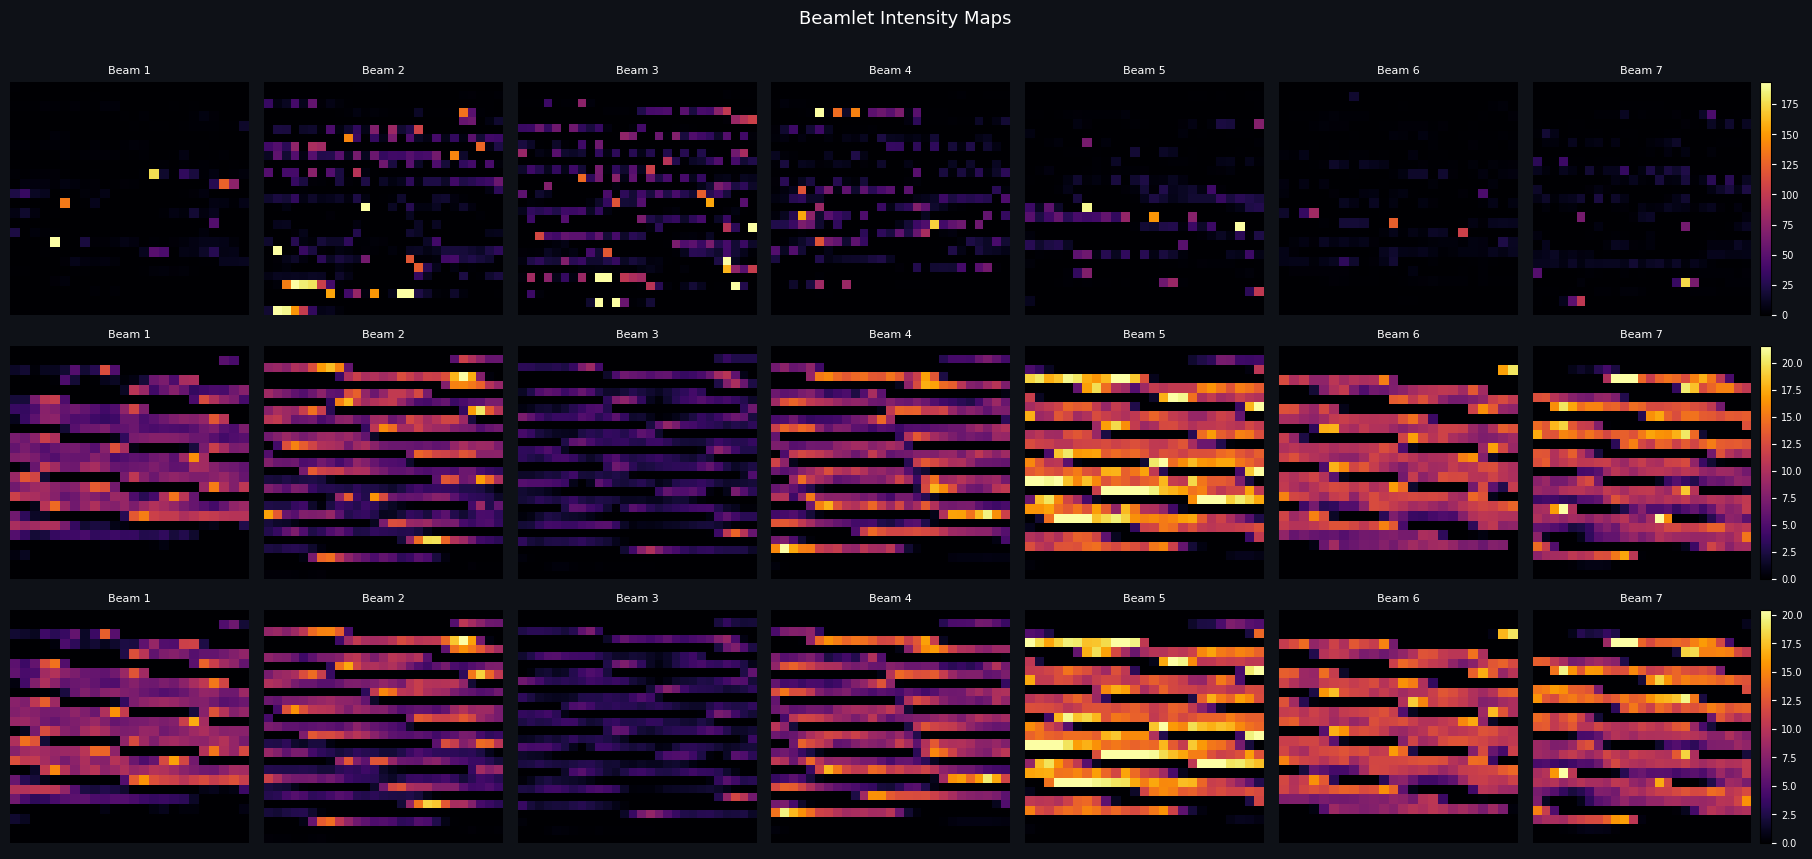

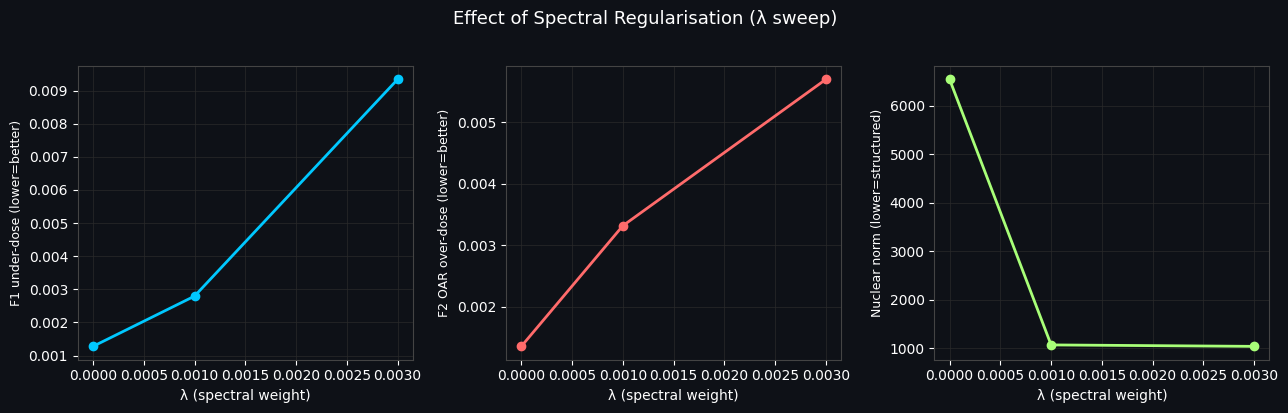

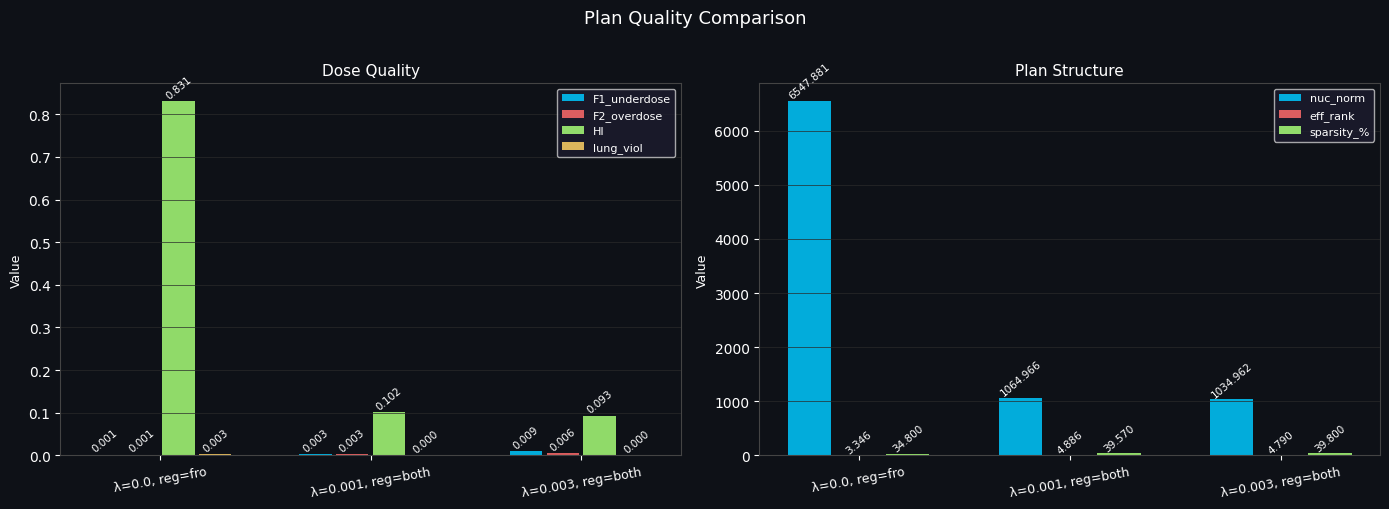


═════════════════════════════════════════════════════════════════════════════════
METRIC                       λ=0.0, reg=fro  λ=0.001, reg=both  λ=0.003, reg=both
═════════════════════════════════════════════════════════════════════════════════

  ── PTV Coverage ──
  D95_ptv                               60.44               60.0               60.0
  D05_ptv                              110.29              66.12              65.56
  Dmean_ptv                             74.42              62.21              61.96
  HI                                   0.8309              0.102             0.0927
  CI_proxy_%                            99.99              99.97              99.92
  F1_underdose                         0.0013             0.0028             0.0093

  ── OAR Sparing ──
  Dmean_esoph                           14.04              12.48              12.11
  Dmax_esoph                            45.83              53.67              52.72
  Dmean_cord                          

In [11]:
# -*- coding: utf-8 -*-
"""Convex_Optimisation.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1CPE6uARZ9eHXsO3f7E7rZpJRcJLH7jxu
"""



"""**CONVEX OPTIMISATION**


"""

#!pip install portpy cvxpy clarabel scipy matplotlib numpy h5py datasets
#!pip install huggingface_hub

import os, json, warnings, time
import h5py
import numpy as np
import scipy.sparse as sp
from scipy.sparse import coo_matrix, hstack
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import snapshot_download

warnings.filterwarnings('ignore')

# ---------------- Clinical dose limits (Gy) ----------------
D_PTV   = 60.0
D_ESOPH = 45.0
D_CORD  = 30.0
D_LUNG  = 20.0

# ---------------- Download dataset ----------------
snapshot_download(
    repo_id="PortPy-Project/PortPy_Dataset",
    repo_type="dataset",
    allow_patterns="data/Lung_Patient_3/*",
    local_dir="./hf_data"
)

# ---------------- Build dose influence matrix A ----------------
beam_dir   = './hf_data/data/Lung_Patient_3/Beams'
beam_files = sorted([
    os.path.join(beam_dir, f)
    for f in os.listdir(beam_dir)
    if f.endswith('_Data.h5')
])

with h5py.File(beam_files[0], 'r') as f:
    n_voxels = f['inf_matrix_full'].shape[0]

A_blocks          = []
beamlets_per_beam = []

for bf in sorted(beam_files):
    with h5py.File(bf, 'r') as f:
        coo_data = f['inf_matrix_sparse'][:]
        n_cols   = f['inf_matrix_full'].shape[1]
        rows = coo_data[:, 0].astype(np.int32)
        cols = coo_data[:, 1].astype(np.int32)
        vals = coo_data[:, 2].astype(np.float32)
        A_beam = coo_matrix((vals, (rows, cols)), shape=(n_voxels, n_cols)).tocsr()
        A_blocks.append(A_beam)
        beamlets_per_beam.append(n_cols)

A = hstack(A_blocks, format='csr')

# ---------------- Load voxel map + structure masks ----------------
with h5py.File('./hf_data/data/Lung_Patient_3/OptimizationVoxels_Data.h5', 'r') as f:
    ct_to_dose = f['ct_to_dose_voxel_map'][:]

with h5py.File('./hf_data/data/Lung_Patient_3/StructureSet_Data.h5', 'r') as f:
    mask_ptv   = f['PTV'][:]
    mask_esoph = f['ESOPHAGUS'][:]
    mask_cord  = f['CORD'][:]
    mask_lung  = f['LUNG_L'][:]

def get_voxel_indices(mask_3d, ct_to_dose_map):
    both = mask_3d.astype(bool) & (ct_to_dose_map >= 0)
    return ct_to_dose_map[both].astype(np.int32)

ptv_voxels   = get_voxel_indices(mask_ptv,   ct_to_dose)
esoph_voxels = get_voxel_indices(mask_esoph, ct_to_dose)
cord_voxels  = get_voxel_indices(mask_cord,  ct_to_dose)
lung_voxels  = get_voxel_indices(mask_lung,  ct_to_dose)

A_ptv   = A[ptv_voxels,   :]
A_esoph = A[esoph_voxels, :]
A_cord  = A[cord_voxels,  :]
A_lung  = A[lung_voxels,  :]

# ---------------- Select planner beams ----------------
with open('./hf_data/data/Lung_Patient_3/PlannerBeams.json') as f:
    planner = json.load(f)

beam_ids = planner if isinstance(planner, list) else list(planner.values())[0]

beam_col_start      = np.cumsum([0] + beamlets_per_beam)
planner_col_indices = np.concatenate([
    np.arange(beam_col_start[b], beam_col_start[b+1])
    for b in beam_ids
])

A_ptv_sp   = A_ptv[:,   planner_col_indices].astype(np.float64).tocsr()
A_esoph_sp = A_esoph[:, planner_col_indices].astype(np.float64).tocsr()
A_cord_sp  = A_cord[:,  planner_col_indices].astype(np.float64).tocsr()
A_lung_sp  = A_lung[:,  planner_col_indices].astype(np.float64).tocsr()

planner_bpb = [beamlets_per_beam[b] for b in beam_ids]
nb          = len(beam_ids)
max_bpb     = max(planner_bpb)
n_beamlets  = sum(planner_bpb)

print(f"Planner beams: {nb}, beamlets per beam: {planner_bpb}")
print(f"Total beamlets: {n_beamlets}")

# ---------------- Safe SVD helper ----------------
def safe_svd(X_np):
    try:
        return np.linalg.svd(X_np + 1e-4 * np.random.randn(*X_np.shape),
                             compute_uv=False)
    except np.linalg.LinAlgError:
        return np.array([np.linalg.norm(X_np, 'fro')])

# ---------------- Convex solver with combined reg option ----------------
def solve_convex_fast(
    A_ptv, A_esoph, A_cord, A_lung,
    nb, bpb,
    w1=10.0, w2=2.0,
    lam=0.0,
    reg_type="both",   # "fro", "group", or "both"
):
    t0 = time.time()

    nP = A_ptv.shape[0]
    nE = A_esoph.shape[0]
    nC = A_cord.shape[0]
    nL = A_lung.shape[0]
    n  = A_ptv.shape[1]

    x = cp.Variable(n, nonneg=True)

    mbpb   = max(bpb)
    starts = np.cumsum([0] + bpb[:-1])

    rows = []
    for i in range(nb):
        s, sz = starts[i], bpb[i]
        if sz < mbpb:
            pad = cp.Constant(np.zeros(mbpb - sz))
            row = cp.hstack([x[s:s+sz], pad])
        else:
            row = x[s:s+sz]
        rows.append(row)

    X_mat = cp.vstack(rows)

    obj_terms = [
        (w1 / nP) * cp.sum(cp.pos(D_PTV   - A_ptv   @ x)),
        (w2 / nE) * cp.sum(cp.pos(A_esoph @ x - D_ESOPH)),
        (w2 / nC) * cp.sum(cp.pos(A_cord  @ x - D_CORD)),
    ]

    if lam > 0:
        if reg_type == "fro":
            obj_terms.append(lam * cp.norm(X_mat, "fro"))

        elif reg_type == "group":
            obj_terms.append(lam * cp.sum(cp.norm(X_mat, axis=1)))

        elif reg_type == "both":
            # Combined spectral proxy:
            # Frobenius → global shrinkage of singular values
            # Group     → row sparsity → fewer active beams / lower effective rank
            lam_fro   = lam
            lam_group = lam
            obj_terms.append(lam_fro   * cp.norm(X_mat, "fro"))
            obj_terms.append(lam_group * cp.sum(cp.norm(X_mat, axis=1)))

        else:
            raise ValueError("reg_type must be 'fro', 'group', or 'both'")

    obj = cp.Minimize(cp.sum(obj_terms))

    constraints = [
        cp.sum(A_lung @ x) / nL <= D_LUNG
    ]

    prob = cp.Problem(obj, constraints)

    try:
        prob.solve(
            solver=cp.OSQP,
            eps_abs=1e-4,
            eps_rel=1e-4,
            max_iter=20000,
            verbose=False
        )
        solver_used = "OSQP"
    except Exception as e:
        print("OSQP failed, falling back to SCS:", e)
        prob.solve(solver=cp.SCS, eps=1e-4, max_iters=10000, verbose=False)
        solver_used = "SCS"

    elapsed = time.time() - t0
    xv = x.value

    if xv is not None:
        F1 = float(np.mean(np.maximum(D_PTV - A_ptv @ xv, 0)))
        F2 = float(
            np.mean(np.maximum(A_esoph @ xv - D_ESOPH, 0)) +
            np.mean(np.maximum(A_cord  @ xv - D_CORD,  0))
        )
    else:
        F1 = F2 = np.nan
        print(f"WARNING: solver failed — status {prob.status}")

    return dict(
        x=xv,
        status=prob.status,
        F1=F1,
        F2=F2,
        lam=lam,
        solve_time=elapsed,
        solver=solver_used,
        label=f'λ={lam}, reg={reg_type}',
    )

# ---------------- Metrics computation ----------------
def compute_metrics(r, A_ptv, A_esoph, A_cord, A_lung, nb, bpb):
    if r['x'] is None:
        return {'label': r.get('label', '?'), 'status': r.get('status', '?')}

    x        = np.maximum(r['x'], 0)
    mbpb     = max(bpb)
    starts   = np.cumsum([0] + bpb[:-1])

    X_np = np.zeros((nb, mbpb))
    for i in range(nb):
        s, sz = starts[i], bpb[i]
        X_np[i, :sz] = x[s:s+sz]

    d_ptv   = np.asarray(A_ptv   @ x).ravel()
    d_esoph = np.asarray(A_esoph @ x).ravel()
    d_cord  = np.asarray(A_cord  @ x).ravel()
    d_lung  = np.asarray(A_lung  @ x).ravel()

    svs      = safe_svd(X_np)
    nuc_norm = float(svs.sum())
    eff_rank = float((svs.sum() ** 2) / ((svs ** 2).sum() + 1e-12))

    return {
        'label'         : r.get('label', '?'),
        'status'        : r.get('status', '?'),
        'solver'        : r.get('solver', '?'),
        'solve_time_s'  : round(r.get('solve_time', np.nan), 1),
        'D95_ptv'       : round(float(np.percentile(d_ptv,  5)), 2),
        'D05_ptv'       : round(float(np.percentile(d_ptv, 95)), 2),
        'Dmean_ptv'     : round(float(d_ptv.mean()), 2),
        'HI'            : round(float((np.percentile(d_ptv, 95) -
                                       np.percentile(d_ptv,  5)) / D_PTV), 4),
        'CI_proxy_%'    : round(float(np.mean(d_ptv >= 0.95 * D_PTV) * 100), 2),
        'F1_underdose'  : round(float(np.mean(np.maximum(D_PTV - d_ptv, 0))), 4),
        'Dmean_esoph'   : round(float(d_esoph.mean()), 2),
        'Dmax_esoph'    : round(float(d_esoph.max()),  2),
        'Dmean_cord'    : round(float(d_cord.mean()), 2),
        'Dmax_cord'     : round(float(d_cord.max()),  2),
        'Dmean_lung'    : round(float(d_lung.mean()), 2),
        'V20_lung_%'    : round(float(np.mean(d_lung >= 20.0) * 100), 2),
        'F2_overdose'   : round(float(
                            np.mean(np.maximum(d_esoph - D_ESOPH, 0)) +
                            np.mean(np.maximum(d_cord  - D_CORD,  0))), 4),
        'lung_viol'     : round(float(max(d_lung.mean() - D_LUNG, 0)), 4),
        'sparsity_%'    : round(float(np.mean(x < 1e-3) * 100), 2),
        'total_MU'      : round(float(x.sum()), 2),
        'nuc_norm'      : round(nuc_norm, 4),
        'eff_rank'      : round(eff_rank, 3),
    }

# ---------------- Run baseline + combined spectral reg ----------------
lam_values = [0.0, 0.001, 0.003]

RESULTS = {}

for lam in lam_values:
    if lam == 0.0:
        tag = "Baseline (no reg)"
        r = solve_convex_fast(
            A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
            nb=nb,
            bpb=planner_bpb,
            w1=10.0,
            w2=2.0,
            lam=0.0,
            reg_type="both"   # reg_type irrelevant when lam=0
        )
    else:
        tag = f"Combined spectral (Fro+Group), λ={lam}"
        r = solve_convex_fast(
            A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
            nb=nb,
            bpb=planner_bpb,
            w1=10.0,
            w2=2.0,
            lam=lam,
            reg_type="both"
        )

    print(f"\n=== {tag} ===")
    print(f"Status : {r['status']}  [{r['solver']}]")
    print(f"F1     : {r['F1']:.4f}")
    print(f"F2     : {r['F2']:.4f}")
    print(f"Time   : {r['solve_time']:.1f}s")

    RESULTS[tag] = r

# ---------------- Build metrics table ----------------
rows = [compute_metrics(r, A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp,
                        nb, planner_bpb)
        for r in RESULTS.values()]
df = pd.DataFrame(rows).set_index('label')

print("\nFull metrics table:")
print(df)

COLORS = ['#00c8ff', '#ff6b6b', '#a8ff78', '#ffd166']


def print_validation_table(df):
    limits = {
        'D95_ptv'    : ('>=', 57.0,  'PTV coverage'),
        'HI'         : ('<=', 0.10,  'PTV homogeneity'),
        'Dmax_esoph' : ('<=', 45.0,  'Esoph sparing'),
        'Dmax_cord'  : ('<=', 30.0,  'Cord sparing'),
        'Dmean_lung' : ('<=', 20.0,  'Lung mean dose'),
    }
    print(f"\n{'='*68}")
    print(f"{'PROTOCOL PASS/FAIL — VALIDATION TABLE':^68}")
    print(f"{'='*68}")
    header = f"  {'Metric':<16} {'Limit':<10}" + \
             "".join(f"{l:>16}" for l in df.index)
    print(header)
    print('-'*68)
    for metric, (op, limit, desc) in limits.items():
        if metric not in df.columns:
            continue
        vals = df[metric].astype(float)
        def flag(v):
            passed = (v >= limit) if op == '>=' else (v <= limit)
            return ' PASS' if passed else ' FAIL'
        limit_str = f"{op}{limit}"
        row = f"  {desc:<16} {limit_str:<10}" + \
              "".join(f"{str(vals[l])+flag(vals[l]):>16}" for l in df.index)
        print(row)
    print('='*68)
    print("  PASS = meets clinical protocol limit for this patient.")
    print("  Single-patient validation: metric compliance vs protocol IS the result.\n")

print_validation_table(df)


# ── SECTION 13: DOSE VOLUME HISTOGRAM ────────────────────────────────────────

def plot_dvh(results_dict, A_ptv, A_esoph, A_cord, A_lung,
             dose_max=80.0, n_bins=300):
    bins    = np.linspace(0, dose_max, n_bins)
    structs = [
        ('PTV',   A_ptv,   D_PTV,   '-',               '#ffffff'),
        ('Esoph', A_esoph, D_ESOPH, '--',               '#ffd166'),
        ('Cord',  A_cord,  D_CORD,  '-.',               '#ff9f43'),
        ('Lung',  A_lung,  D_LUNG,  (0,(3,1,1,1,1,1)), '#a29bfe'),
    ]
    n_res  = len(results_dict)
    fig, axes = plt.subplots(1, n_res, figsize=(7*n_res, 5), sharey=True,
                             facecolor='#0e1117')
    if n_res == 1:
        axes = [axes]

    for ax, (label, r), col in zip(axes, results_dict.items(), COLORS):
        if r['x'] is None:
            ax.set_title(f'{label}\n(no solution)', color='white')
            continue
        x = np.maximum(r['x'], 0)
        for sname, Am, limit, ls, sc in structs:
            dose = np.asarray(Am @ x).ravel()
            dvh  = np.array([(dose >= d).mean() * 100 for d in bins])
            ax.plot(bins, dvh, color=sc, linestyle=ls, linewidth=2, label=sname)
            ax.axvline(limit, color=sc, linewidth=0.6, linestyle=':', alpha=0.45)

        d95 = np.percentile(np.asarray(A_ptv @ x).ravel(), 5)
        ax.annotate(f'D95={d95:.1f}Gy', xy=(d95, 95), xytext=(d95+3, 85),
                    color='white', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='white', lw=0.8))

        ax.set_facecolor('#0e1117')
        ax.set_title(label, color='white', fontsize=11)
        ax.set_xlabel('Dose (Gy)', color='white')
        if ax is axes[0]:
            ax.set_ylabel('Volume (%)', color='white')
        ax.tick_params(colors='white')
        ax.set_xlim(0, dose_max); ax.set_ylim(0, 105)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.grid(True, color='#2a2a2a', linewidth=0.5)
        ax.legend(facecolor='#1c1c2e', labelcolor='white', fontsize=9)

    plt.suptitle('Dose Volume Histogram', color='white', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('dvh.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 14: BEAMLET INTENSITY MAPS ───────────────────────────────────────

def plot_beamlet_maps(results_dict, bpb, cmap='inferno'):
    n_res = len(results_dict)
    nb_   = len(bpb)
    fig, axes = plt.subplots(n_res, nb_, figsize=(nb_*2.6, n_res*2.8),
                             facecolor='#0e1117', squeeze=False)
    for row, (label, r) in enumerate(results_dict.items()):
        if r['x'] is None:
            continue
        x      = np.maximum(r['x'], 0)
        offset = 0
        vmax   = max(x[offset:offset+b].max() + 1e-9 for b in bpb)
        for col, n_beamlets in enumerate(bpb):
            ax     = axes[row, col]
            beam_x = x[offset:offset + n_beamlets]
            offset += n_beamlets
            side   = int(np.ceil(np.sqrt(n_beamlets)))
            padded = np.zeros(side * side)
            padded[:n_beamlets] = beam_x
            im = ax.imshow(padded.reshape(side, side), cmap=cmap,
                           aspect='auto', vmin=0, vmax=vmax, interpolation='nearest')
            ax.set_title(f'Beam {col+1}', color='white', fontsize=8)
            ax.axis('off')
            if col == nb_ - 1:
                cb = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
                cb.ax.tick_params(colors='white', labelsize=7)
        axes[row, 0].set_ylabel(label, color='white', fontsize=9)

    plt.suptitle('Beamlet Intensity Maps', color='white', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('beamlet_maps.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 15: LAMBDA SWEEP — SPECTRAL EFFECT PLOT ──────────────────────────
#
# This plot is your main result: shows how increasing λ changes
# nuclear norm (plan structure) vs dose quality (F1, F2).
# With one patient this IS the experiment.

def plot_lambda_sweep(results_dict):
    lams  = [r['lam']           for r in results_dict.values() if r['x'] is not None]
    f1s   = [r['F1']            for r in results_dict.values() if r['x'] is not None]
    f2s   = [r['F2']            for r in results_dict.values() if r['x'] is not None]
    norms = []
    for r in results_dict.values():
        if r['x'] is None:
            continue
        x = np.maximum(r['x'], 0)
        starts = np.cumsum([0] + planner_bpb[:-1])
        X_np   = np.zeros((nb, max_bpb))
        for i in range(nb):
            s, sz = starts[i], planner_bpb[i]
            X_np[i, :sz] = x[s:s+sz]
        svs = safe_svd(X_np)
        norms.append(float(svs.sum()))

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor='#0e1117')
    for ax, yvals, ylabel, col in [
        (axes[0], f1s,   'F1 under-dose (lower=better)',  '#00c8ff'),
        (axes[1], f2s,   'F2 OAR over-dose (lower=better)','#ff6b6b'),
        (axes[2], norms, 'Nuclear norm (lower=structured)', '#a8ff78'),
    ]:
        ax.plot(lams, yvals, 'o-', color=col, linewidth=2, markersize=6)
        ax.set_facecolor('#0e1117')
        ax.set_xlabel('λ (spectral weight)', color='white')
        ax.set_ylabel(ylabel, color='white', fontsize=9)
        ax.tick_params(colors='white')
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.grid(color='#2a2a2a', linewidth=0.5)

    plt.suptitle('Effect of Spectral Regularisation (λ sweep)',
                 color='white', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('lambda_sweep.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 16: COMPARISON BAR CHARTS ────────────────────────────────────────

def plot_comparison_bars(df_metrics):
    metric_groups = {
        'Dose Quality'   : ['F1_underdose', 'F2_overdose', 'HI', 'lung_viol'],
        'Plan Structure' : ['nuc_norm', 'eff_rank', 'sparsity_%'],
    }
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0e1117')
    labels = df_metrics.index.tolist()
    x_base = np.arange(len(labels))

    for ax, (grp_name, metrics) in zip(axes, metric_groups.items()):
        n_m   = len(metrics)
        width = 0.7 / n_m
        ax.set_facecolor('#0e1117')
        for i, metric in enumerate(metrics):
            if metric not in df_metrics.columns:
                continue
            vals = df_metrics[metric].astype(float).values
            col  = COLORS[i % len(COLORS)]
            bars = ax.bar(x_base + i*width - (n_m-1)*width/2,
                          vals, width*0.88, label=metric, color=col, alpha=0.85)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.002, f'{val:.3f}',
                        ha='center', va='bottom', color='white',
                        fontsize=7.5, rotation=40)
        ax.set_xticks(x_base)
        ax.set_xticklabels(labels, color='white', fontsize=9, rotation=10)
        ax.tick_params(colors='white')
        ax.set_title(grp_name, color='white', fontsize=11)
        ax.set_ylabel('Value', color='white', fontsize=9)
        for sp in ax.spines.values():
            sp.set_edgecolor('#444')
        ax.legend(facecolor='#1c1c2e', labelcolor='white', fontsize=8)
        ax.grid(axis='y', color='#2a2a2a', linewidth=0.5)

    plt.suptitle('Plan Quality Comparison', color='white', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('comparison_bars.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# ── SECTION 17: RUN ALL PLOTS AND PRINT FINAL TABLE ──────────────────────────

plot_dvh(RESULTS, A_ptv_sp, A_esoph_sp, A_cord_sp, A_lung_sp)
plot_beamlet_maps(RESULTS, planner_bpb)
plot_lambda_sweep(RESULTS)
plot_comparison_bars(df)

# Full metrics table
groups = {
    'PTV Coverage' : ['D95_ptv','D05_ptv','Dmean_ptv','HI','CI_proxy_%','F1_underdose'],
    'OAR Sparing'  : ['Dmean_esoph','Dmax_esoph','Dmean_cord','Dmax_cord',
                      'Dmean_lung','V20_lung_%','F2_overdose','lung_viol'],
    'Plan Quality' : ['sparsity_%','total_MU','nuc_norm','eff_rank','solve_time_s'],
}
col_w  = max(18, max(len(l) for l in df.index) + 2)
header = f"{'METRIC':<24}" + "".join(f"{l:>{col_w}}" for l in df.index)
print('\n' + '═' * len(header))
print(header)
print('═' * len(header))
for grp, keys in groups.items():
    print(f'\n  ── {grp} ──')
    for k in keys:
        if k not in df.columns:
            continue
        row = "".join(f"{str(df.loc[l,k]):>{col_w}}" for l in df.index)
        print(f"  {k:<24}{row}")
print('═' * len(header))















In [7]:
!pip install scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)


In [10]:
!pip install cvxpy
!pip install matplotlib
!pip install numpy
!pip install h5py
!pip install datasets
!pip install huggingface_hub
!pip install portpy
!pip install pandas
!pip install seaborn

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----

  error: subprocess-exited-with-error
  
  × Building wheel for ecos (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      C:\Users\chatu\AppData\Local\Temp\pip-build-env-vf8nuh0k\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\ecos
      copying src\ecos\ecos.py -> build\lib.win-amd64-cpython-314\ecos
      copying src\ecos\version.py -> build\lib.win-amd64-cpython-314\ecos
      copying src\ecos\__init__.py -> build\lib.win-amd64-cpython-314\ecos
      running build_ext
      building '_ecos' extension
      error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/
      [end of output]
  
  note: This error originates from a subprocess, 

In [3]:
!pip install h5py 

  Using cached h5py-3.16.0-cp314-cp314-win_amd64.whl.metadata (3.1 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
Using cached h5py-3.16.0-cp314-cp314-win_amd64.whl (3.2 MB)
Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl (12.4 MB)

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   -----